# День 5 — Fine-tuning модели

**Цель:** дообучить трансформер на SST-2.

Ключевое отличие от Дня 4: там модель была **заморожена** (`torch.no_grad()`), учился только линейный классификатор поверх CLS. Здесь обучается **вся модель целиком** — градиенты идут через все 6 слоёв DistilBERT.

Переиспользуемый код — в [`finetune_utils.py`](finetune_utils.py).

> **Важно для Дня 6:** разбиение данных здесь намеренно совпадает с Днём 4 (те же `n_samples=3000`, `test_size=0.2`, `random_state=42`, `stratify`). Проверено: валидационная выборка тут — это ровно те же 600 примеров, на которых замерялся baseline. Иначе сравнение было бы нечестным.

## Задача 1: Подготовка Dataset класса

In [1]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long),
        }

C:\Users\Vsevolod\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Почему `max_length=64`, а не 128

`padding='max_length'` дополняет **каждый** текст до `max_length`, то есть модель считает attention и по паддингу тоже. Посмотрим на реальные длины текстов в SST-2:

In [2]:
import numpy as np
from baseline_utils import load_sst2

df = load_sst2(n_samples=3000, random_state=42)
lens = [len(tokenizer.tokenize(t)) for t in df['text']]

print(f'Длины в токенах: медиана={np.percentile(lens, 50):.0f}, '
      f'p90={np.percentile(lens, 90):.0f}, max={max(lens)}')
print(f'\nПри max_length=128 полезной работы: {np.mean(lens)/128:.1%}')
print(f'При max_length=64  полезной работы: {np.mean(lens)/64:.1%}')
print(f'\nОбрезано текстов при max_length=64: {sum(l > 64 for l in lens)}')

Длины в токенах: медиана=8, p90=25, max=64

При max_length=128 полезной работы: 8.8%
При max_length=64  полезной работы: 17.5%

Обрезано текстов при max_length=64: 0


Максимум ровно 64 токена — значит `max_length=64` **не обрезает ни одного текста**, но вдвое сокращает вычисления. На CPU это 3.4 мин/эпоху вместо 7.0. Бесплатное ускорение.

> Ещё быстрее была бы *динамическая* набивка (padding до самого длинного текста **в батче**, а не до глобального максимума) через `DataCollatorWithPadding`. При медиане 8 токенов это дало бы ещё ~3–4×. Здесь оставляем `padding='max_length'` как в задании — проще и детерминированнее.

## Задача 2: Загрузка и подготовка данных

В задании предполагался `pd.read_csv('your_dataset.csv')`. У нас датасет берётся из SST-2 через `load_sst2` (День 4) — те же самые данные.

In [3]:
from sklearn.model_selection import train_test_split

texts = df['text'].tolist()
labels = df['label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')

# Проверим, что отдаёт один элемент
sample = train_dataset[0]
for k, v in sample.items():
    print(f'  {k}: {tuple(v.shape) if v.dim() else "scalar"} {v.dtype}')

Train: 2400, Val: 600
  input_ids: (64,) torch.int64
  attention_mask: (64,) torch.int64
  labels: scalar torch.int64


## Задача 3: Загрузка модели для классификации

In [4]:
from transformers import AutoModelForSequenceClassification
from torch.utils.data import DataLoader

num_labels = len(set(labels))
print(f'Классов: {num_labels}')

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print(f'Батчей в train: {len(train_loader)}, в val: {len(val_loader)}')

Классов: 2


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8832.16it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Батчей в train: 150, в val: 38


При загрузке появляется предупреждение, что веса `classifier` и `pre_classifier` инициализированы случайно (MISSING). Это **ожидаемо**: в предобученном DistilBERT головы классификации нет, она создаётся с нуля — её и предстоит обучить вместе с остальной моделью.

## Задача 4: Настройка обучения


In [5]:
from sklearn.metrics import accuracy_score, f1_score

# НЕ: from transformers import AdamW  ← удалён в transformers 5.x
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f'Device: {device}')
print(f'Обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Device: cpu
Обучаемых параметров: 66,955,010


Обратите внимание на число обучаемых параметров — около 67 млн. В Дне 4 обучалось 769 (768 весов + свободный член). Разница в 87 000 раз: вот что значит fine-tuning против замороженных признаков.

## Задача 5: Функция для обучения одной эпохи

In [6]:
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Передаём labels — модель сама посчитает CrossEntropy loss
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

## Задача 6: Функция для оценки

In [7]:
def evaluate(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            preds = torch.argmax(outputs.logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')

    return accuracy, f1

In [8]:
# Качество ДО обучения — голова классификации ещё случайная
acc0, f1_0 = evaluate(model, val_loader, device)
print(f'До обучения: accuracy={acc0:.4f}, macro F1={f1_0:.4f}')
print('(случайная голова — ожидаем околослучайное качество)')

До обучения: accuracy=0.5583, macro F1=0.3583
(случайная голова — ожидаем околослучайное качество)


## Задача 7: Обучение модели

На CPU это самый долгий шаг: ~3.4 мин на эпоху, итого ~12–15 минут с учётом валидации.

In [9]:
from finetune_utils import run_training

# Та же логика (train_epoch + evaluate по эпохам), что мы написали выше,
# упакована в один вызов. Два важных отличия от наивного цикла:
#   1) seed фиксируется ДО создания модели — случайная инициализация головы
#      классификации тоже становится воспроизводимой;
#   2) после обучения восстанавливаются веса эпохи с ЛУЧШЕЙ val F1, а не
#      последней (3-я эпоха часто уже переобучается).
# Поэтому результат run_training детерминирован и совпадает с сохранённой
# моделью и fine_tuned_results.txt. Модель, созданную выше для демонстрации
# MISSING-весов, run_training не использует — он создаёт свою под seed.
num_epochs = 3
model, hist = run_training(train_dataset, val_dataset, num_epochs=num_epochs)

# Разложим историю в прежний формат — для графиков ниже.
history = {'loss': hist.train_loss, 'acc': hist.val_accuracy, 'f1': hist.val_f1}
val_f1 = hist.best_f1  # F1 сохранённой (лучшей) эпохи — её сравниваем с baseline

Epoch 1/3
Train Loss: 0.4660
Val Accuracy: 0.8850
Val F1: 0.8826  <- best so far
--------------------------------------------------
Epoch 2/3
Train Loss: 0.2110
Val Accuracy: 0.9117
Val F1: 0.9106  <- best so far
--------------------------------------------------
Epoch 3/3
Train Loss: 0.0819
Val Accuracy: 0.9067
Val F1: 0.9059
--------------------------------------------------
Восстановлены веса лучшей эпохи: 2 (val F1=0.9106)


## Задача 8: Сохранение модели

In [10]:
from finetune_utils import save_model, save_metrics

# run_training уже восстановил веса лучшей эпохи — сохраняем именно их.
save_model(model, tokenizer, './fine_tuned_model')

# Метрики пишем в том же формате, что и finetune_utils.save_metrics:
# с разбивкой по эпохам и явной пометкой сохранённой (лучшей) эпохи.
save_metrics(hist, baseline_f1=0.8630)

print('Сохранено: ./fine_tuned_model, fine_tuned_results.txt\n')
print(open('fine_tuned_results.txt', encoding='utf-8').read())

Сохранено: ./fine_tuned_model, fine_tuned_results.txt

Fine-tuning DistilBERT (День 5)
Saved model — epoch 2 (лучшая по val F1)
Validation F1: 0.9106
Validation Accuracy: 0.9117

По эпохам:
  epoch 1: loss=0.4660  acc=0.8850  f1=0.8826
  epoch 2: loss=0.2110  acc=0.9117  f1=0.9106  <- сохранена
  epoch 3: loss=0.0819  acc=0.9067  f1=0.9059

Baseline (День 4, замороженная модель): 0.8630
Прирост от fine-tuning: +0.0476


> Папка `fine_tuned_model/` весит ~256 МБ и хранится в репозитории через **Git LFS** (см. `.gitattributes`: `*.safetensors` под фильтром lfs). Так Дни 6–7 могут просто загрузить готовую модель, не переобучая её.

## Сравнение с baseline (задел на День 6)

In [11]:
BASELINE_F1 = 0.8630  # День 4, замороженная модель + LogisticRegression

print(f'{"Подход":<38} {"macro F1":>9}')
print('-' * 49)
print(f'{"День 4: заморожен + LogReg":<38} {BASELINE_F1:>9.4f}')
print(f'{"День 5: fine-tuning":<38} {val_f1:>9.4f}')
print('-' * 49)
print(f'{"Прирост":<38} {val_f1 - BASELINE_F1:>+9.4f}')

Подход                                  macro F1
-------------------------------------------------
День 4: заморожен + LogReg                0.8630
День 5: fine-tuning                       0.9106
-------------------------------------------------
Прирост                                  +0.0476


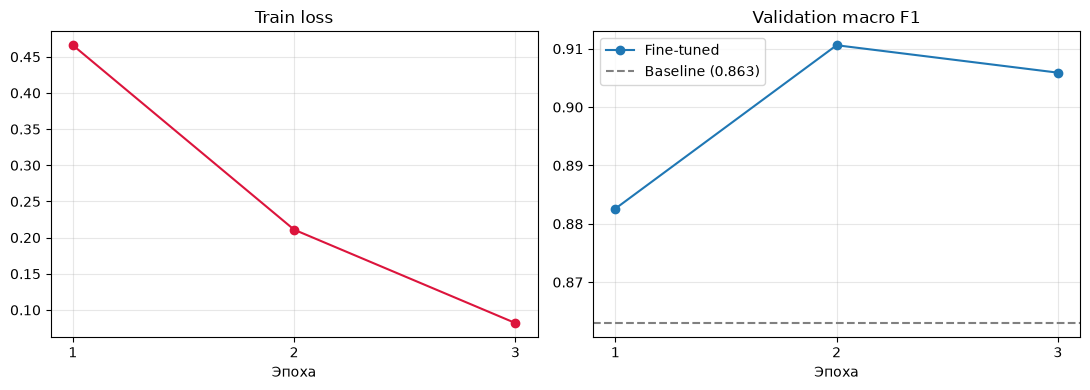

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs = range(1, num_epochs + 1)

axes[0].plot(epochs, history['loss'], marker='o', color='crimson')
axes[0].set_title('Train loss')
axes[0].set_xlabel('Эпоха')
axes[0].set_xticks(list(epochs))
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['f1'], marker='o', label='Fine-tuned')
axes[1].axhline(BASELINE_F1, ls='--', color='gray', label=f'Baseline ({BASELINE_F1:.3f})')
axes[1].set_title('Validation macro F1')
axes[1].set_xlabel('Эпоха')
axes[1].set_xticks(list(epochs))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Чекпоинт

- ✅ Обученная fine-tuned модель
- ✅ Функции `train_epoch` и `evaluate`
- ✅ Модель сохранена в `./fine_tuned_model`
- ✅ Метрики зафиксированы в `fine_tuned_results.txt`

Переиспользуемый код — в [`finetune_utils.py`](finetune_utils.py). В День 6 сравним подробнее.

### На что смотреть

Если train loss падает, а val F1 перестал расти (или пошёл вниз) — это **переобучение**. При 2400 примерах и 67 млн параметров это типично уже на 2–3 эпохе. В таком случае берут модель с лучшей эпохи, а не с последней; в `finetune_utils.TrainingHistory` для этого есть свойство `best_f1`.